In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, confusion_matrix, ConfusionMatrixDisplay, recall_score

## Load & Inspect

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/cybersecurity_intrusion_data.csv")
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB


In [5]:
df.isnull().sum()

,0
session_id,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0


In [35]:
df.shape

(9537, 10)

## EDA

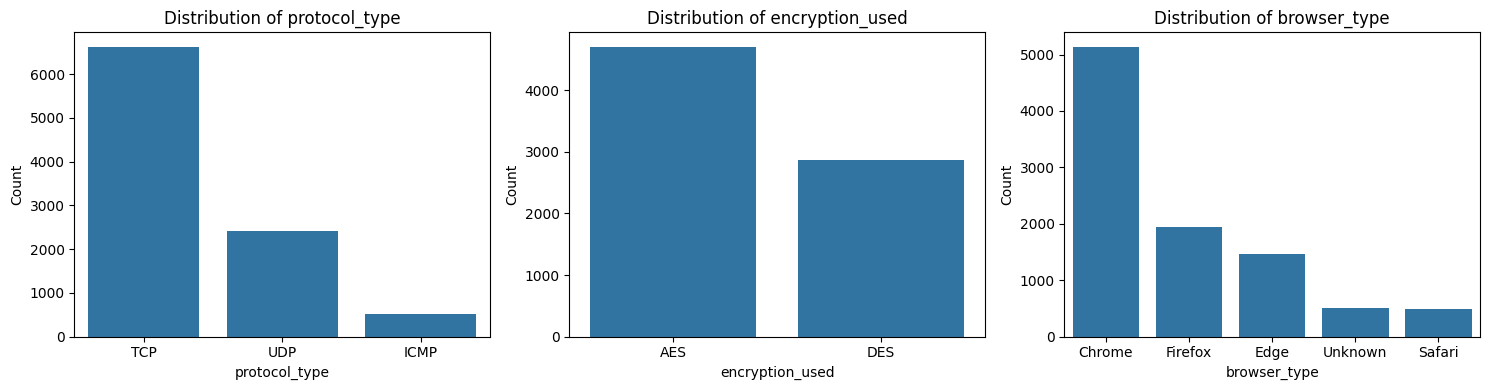

In [6]:
cat_cols = ["protocol_type", "encryption_used", "browser_type"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

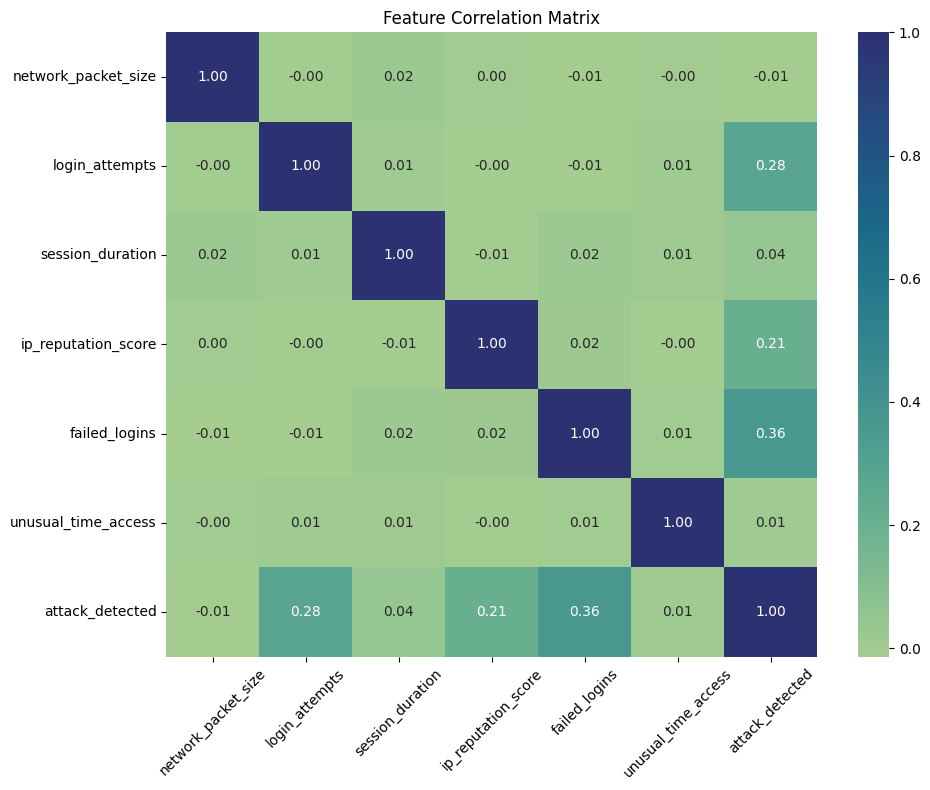

In [37]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f",cmap="crest")

plt.title("Feature Correlation Matrix")
plt.xticks(rotation=45, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

<Axes: xlabel='attack_detected'>

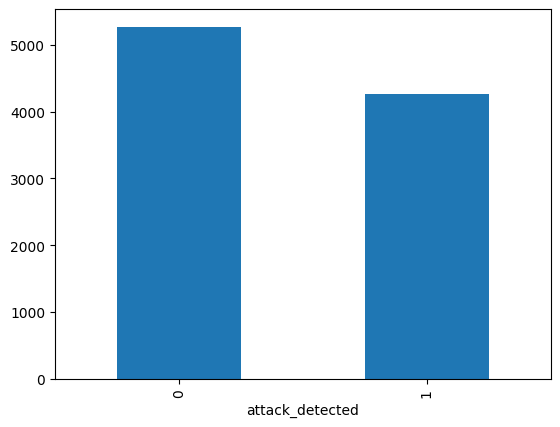

In [36]:
df["attack_detected"].value_counts().plot(kind="bar")

## Preprocess

In [8]:
df.drop(columns=["session_id"], inplace=True)

In [9]:
df["encryption_used"] = df["encryption_used"].fillna(df["encryption_used"].mode()[0])

df.isnull().sum()

,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,0
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0
attack_detected,0


In [11]:
X = df.drop("attack_detected", axis=1)
y = df["attack_detected"]

In [12]:
x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.20, random_state=42)

print("Train data len : ", len(x_train))
print("Test data len : ", len(x_test))

Train data len :  7629
Test data len :  1908


In [13]:
lbe = LabelEncoder()

x_train["encryption_used"] = lbe.fit_transform(x_train["encryption_used"])
x_test["encryption_used"]  = lbe.transform(x_test["encryption_used"])

In [14]:
multi_cat = ["protocol_type", "browser_type"]

x_train = pd.get_dummies(x_train, columns=multi_cat, drop_first=True, dtype=int)
x_test = pd.get_dummies(x_test, columns=multi_cat, drop_first=True, dtype=int)

In [15]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Train Models

In [16]:
models = {
    "Decision Tree" : DecisionTreeClassifier(random_state=42),
    "KNN" : KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42)
}

results, predictions = {}, {}

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    
    predictions[name] = y_pred
    results[name] = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision" : precision_score(y_test, y_pred),
        "Recall" : recall_score(y_test, y_pred),
        "F1-Score" : f1_score(y_test, y_pred)
    }

## Evaluate

In [17]:
result_df = pd.DataFrame(results).T

result_df

,Accuracy,Precision,Recall,F1-Score
Decision Tree,0.812893,0.791765,0.788980,0.790370
KNN,0.791405,0.861685,0.635404,0.731444
Logistic Regression,0.728512,0.717815,0.647128,0.680641


In [18]:
for name, y_pred in predictions.items():
    print(f"\n{'-' * 20} \n {name} \n {'-' * 20}")
    print(classification_report(y_test, y_pred, digits=4))


-------------------- 
 Decision Tree 
 --------------------
              precision    recall  f1-score   support

           0     0.8299    0.8322    0.8310      1055
           1     0.7918    0.7890    0.7904       853

    accuracy                         0.8129      1908
   macro avg     0.8108    0.8106    0.8107      1908
weighted avg     0.8128    0.8129    0.8129      1908


-------------------- 
 KNN 
 --------------------
              precision    recall  f1-score   support

           0     0.7568    0.9175    0.8295      1055
           1     0.8617    0.6354    0.7314       853

    accuracy                         0.7914      1908
   macro avg     0.8093    0.7765    0.7805      1908
weighted avg     0.8037    0.7914    0.7857      1908


-------------------- 
 Logistic Regression 
 --------------------
              precision    recall  f1-score   support

           0     0.7357    0.7943    0.7639      1055
           1     0.7178    0.6471    0.6806       853

   

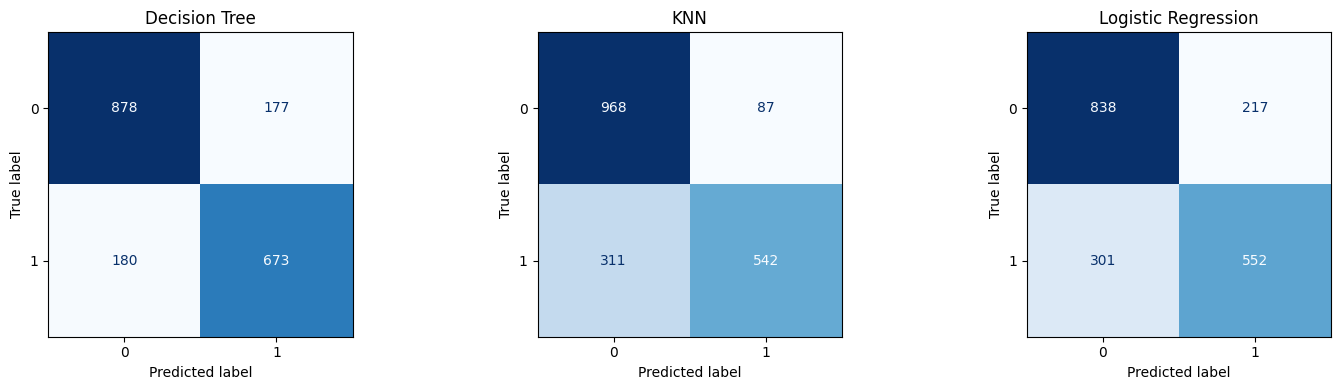

In [19]:
fig, axes = plt.subplots(1, len(predictions), figsize=(5 * len(predictions), 4))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues", ax=ax, colorbar=False)
    
    ax.grid(False)
    ax.set_title(f"{name}")

plt.tight_layout()
plt.show()

## Depth Tuning

In [20]:
tune_decisionTree_results = []

for depth in [3, 5, 10, 15, 20, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(x_train_scaled, y_train)
    
    y_pred = model.predict(x_test_scaled)
    
    tune_decisionTree_results.append({
        'max_depth': str(depth) or 'None',
        'Accuracy': accuracy_score(y_test, y_pred), 
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred), 
        'F1-Score': f1_score(y_test, y_pred)
    })
    
    
decisionTree_results_df = pd.DataFrame(tune_decisionTree_results).set_index('max_depth')
print(decisionTree_results_df.round(4))

           Accuracy  Precision  Recall  F1-Score
max_depth                                       
3            0.8643     1.0000  0.6964    0.8210
5            0.8842     1.0000  0.7409    0.8512
10           0.8816     0.9845  0.7468    0.8493
15           0.8705     0.9417  0.7573    0.8395
20           0.8438     0.8618  0.7749    0.8160
None         0.8129     0.7918  0.7890    0.7904


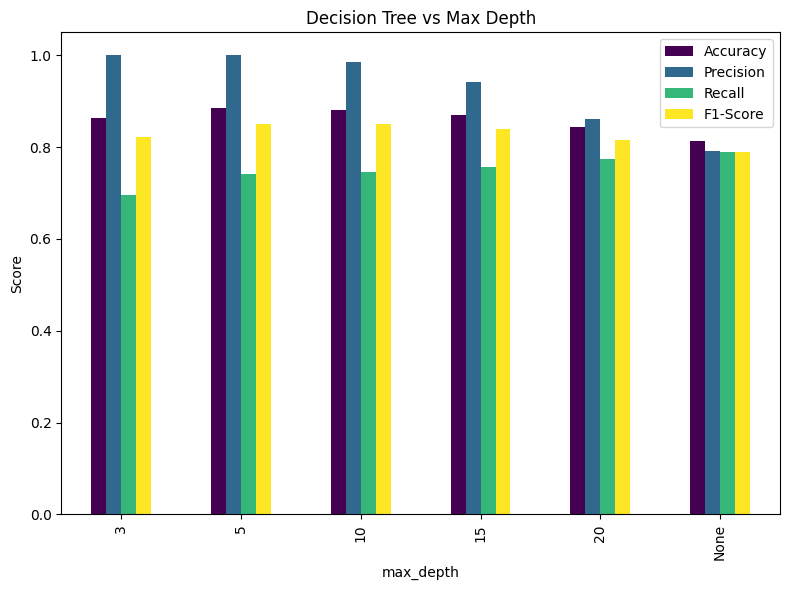

In [23]:
decisionTree_results_df.plot(kind='bar', figsize=(8, 6), colormap='viridis')
plt.title('Decision Tree vs Max Depth') 
plt.ylabel('Score')
plt.tight_layout()
plt.show()

## Final model comparison

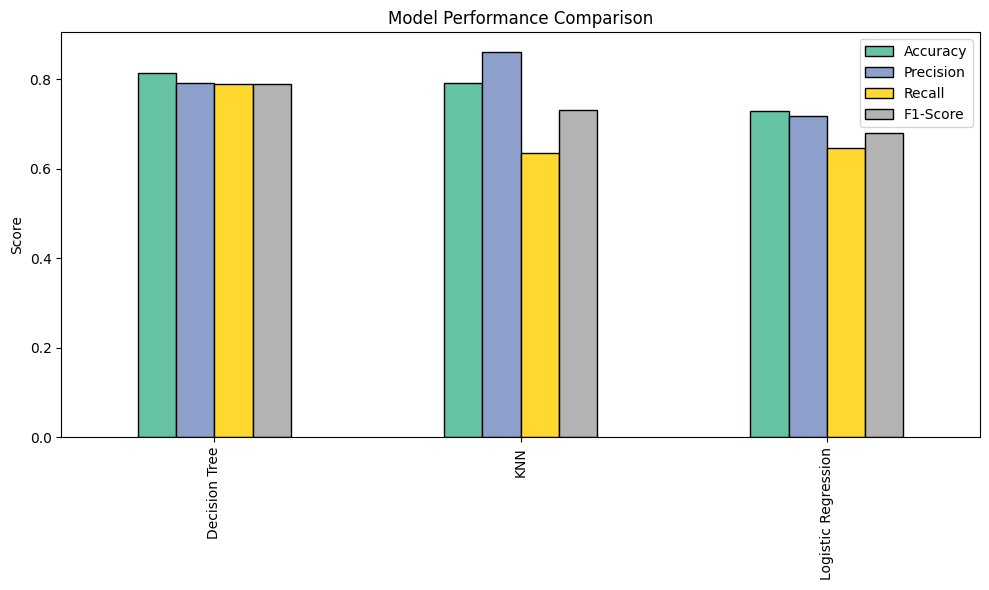

In [28]:
result_df.plot(kind='bar', figsize=(10, 6), colormap='Set2', edgecolor='black')

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

In [29]:
print("Summary:\n", result_df.round(4))

Summary:
                      Accuracy  Precision  Recall  F1-Score
Decision Tree          0.8129     0.7918  0.7890    0.7904
KNN                    0.7914     0.8617  0.6354    0.7314
Logistic Regression    0.7285     0.7178  0.6471    0.6806
